In [9]:
# import numpy as np
# import pandas as pd

# import matplotlib.pyplot as plt 
# import seaborn as sns

# import joblib


# %matplotlib inline

### Parsing the caliberated CFLIB library data in dataframe using tab delimiter

In [10]:
# df = pd.read_csv("asu (2).tsv", delimiter = "\t", encoding = "latin1")

In [11]:
# df.head()

In [12]:
# df.drop([0,1], inplace = True)

In [13]:
# df.reset_index(drop = True, inplace= True)

In [14]:
# df.head()

#### Testing the interpolator pipeline

In [2]:
INTERPOLATOR_MODEL = 'RF_base_model_pvk.sav'
STANDARD_SCALER = 'rf_standard_scale_pvk.sav'

In [1]:
import scipy 

print(scipy.__version__)
print(scipy.__file__)

1.1.0
/home/arbiter/projects2/Recalibration-deep-learning/.venv36/lib/python3.6/site-packages/scipy/__init__.py


In [1]:


from sklearn.externals import joblib
model = joblib.load("RF_base_model_pvk.sav")
print(type(model))

# import joblib
# model = joblib.load("RF_base_model_pvk.sav")
# print(type(model))



/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/ensemble/weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


<class 'sklearn.ensemble.forest.RandomForestRegressor'>


/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator RandomForestRegressor from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


In [3]:
sc = joblib.load(STANDARD_SCALER)
ip = joblib.load(INTERPOLATOR_MODEL)

/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator StandardScaler from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
ip.n_jobs = 1 

def InterpolateSpectrum(temperature, gravity, metallicity):
    X = np.array([temperature, gravity, metallicity]).reshape(1, -1)
    X_std = sc.transform(X)
    y = ip.predict(X_std)
    return y

In [10]:
pred = InterpolateSpectrum(5040,3.5,0.0)

In [13]:
wave = 3500. + np.arange(4306, dtype=np.float)*0.9

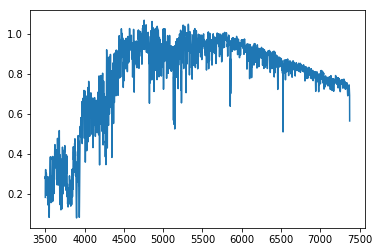

In [14]:
plt.plot(wave,pred[0,:])
plt.show()